In [ ]:
#library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING

In [ ]:
#import data
ipi = pd.read_csv("/content/ipi.csv")
lfs = pd.read_csv("/content/lfs_month_duration.csv")

In [ ]:
ipi.head()

,series,date,index,index_sa
0,abs,2015-01-01,101.029,101.011
1,abs,2015-02-01,90.812,98.808
2,abs,2015-03-01,101.660,98.567
3,abs,2015-04-01,97.041,98.377
4,abs,2015-05-01,100.677,100.157


In [ ]:
lfs.head()

,date,unemployed,unemployed_active,unemployed_active_3mo,unemployed_active_6mo,unemployed_active_12mo,unemployed_active_long,unemployed_inactive
0,2016-01-01,501.5,361.9,180.3,110.0,36.0,35.6,139.7
1,2016-02-01,506.4,254.0,115.8,83.7,34.9,19.6,252.4
2,2016-03-01,509.5,332.8,176.8,92.9,44.8,18.3,176.7
3,2016-04-01,511.5,328.0,170.6,93.3,43.9,20.2,183.4
4,2016-05-01,504.8,297.3,153.6,92.5,37.6,13.6,207.6


In [ ]:
#change date format to match
lfs['date'] = pd.to_datetime(lfs['date'])
lfs = lfs.set_index('date')
ipi['date'] = pd.to_datetime(ipi['date'])
ipi = ipi.set_index('date')

In [ ]:
#merge by date
dt = pd.merge(ipi, lfs, on='date', how='outer')
dt.head()

,series,index,index_sa,unemployed,unemployed_active,unemployed_active_3mo,unemployed_active_6mo,unemployed_active_12mo,unemployed_active_long,unemployed_inactive
date,,,,,,,,,,
2015-01-01,abs,101.029,101.011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,abs,90.812,98.808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,growth_mom,-10.113,-2.181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-01,abs,101.660,98.567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-01,growth_mom,11.946,-0.243,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dt.isnull().sum()

,0
series,0
index,0
index_sa,0
unemployed,23
unemployed_active,23
unemployed_active_3mo,23
unemployed_active_6mo,23
unemployed_active_12mo,23
unemployed_active_long,23
unemployed_inactive,23


In [ ]:
dt.dropna(inplace=True)
dt.isnull().sum()

,0
series,0
index,0
index_sa,0
unemployed,0
unemployed_active,0
unemployed_active_3mo,0
unemployed_active_6mo,0
unemployed_active_12mo,0
unemployed_active_long,0
unemployed_inactive,0


In [ ]:
dt.duplicated().sum()

np.int64(0)

In [ ]:
dt.head()

,series,index,index_sa,unemployed,unemployed_active,unemployed_active_3mo,unemployed_active_6mo,unemployed_active_12mo,unemployed_active_long,unemployed_inactive
date,,,,,,,,,,
2016-01-01,abs,104.303,102.100,501.5,361.9,180.3,110.0,36.0,35.6,139.7
2016-01-01,growth_yoy,3.240,1.078,501.5,361.9,180.3,110.0,36.0,35.6,139.7
2016-01-01,growth_mom,0.691,2.518,501.5,361.9,180.3,110.0,36.0,35.6,139.7
2016-02-01,abs,94.629,102.700,506.4,254.0,115.8,83.7,34.9,19.6,252.4
2016-02-01,growth_yoy,4.204,3.939,506.4,254.0,115.8,83.7,34.9,19.6,252.4


# ORGANISATION OF DATA

# (1) Descriptive Statistic

In [ ]:
#numerical summaries
dt.describe()

,index,index_sa,unemployed,unemployed_active,unemployed_active_3mo,unemployed_active_6mo,unemployed_active_12mo,unemployed_active_long,unemployed_inactive
count,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,40.767425,40.775020,580.897436,437.708547,235.287179,110.657265,55.888034,35.872650,143.188889
std,55.692896,55.654507,89.898435,105.256601,71.517281,25.662365,15.419823,13.456766,40.526681
min,-31.613000,-31.756000,501.500000,254.000000,110.900000,74.700000,34.300000,13.600000,96.000000
25%,1.211000,0.484000,515.200000,347.800000,161.700000,90.000000,45.200000,27.200000,113.500000
50%,4.146000,3.448000,533.800000,423.600000,268.800000,103.900000,50.200000,31.000000,125.300000
75%,111.119000,110.960000,610.500000,491.300000,297.100000,125.700000,64.900000,43.300000,174.400000
max,141.011000,140.640000,826.100000,657.200000,351.400000,175.900000,92.000000,73.100000,319.000000


In [ ]:
dt.mean(numeric_only=True)

,0
index,40.767425
index_sa,40.775020
unemployed,580.897436
unemployed_active,437.708547
unemployed_active_3mo,235.287179
unemployed_active_6mo,110.657265
unemployed_active_12mo,55.888034
unemployed_active_long,35.872650
unemployed_inactive,143.188889


In [ ]:
dt.median(numeric_only=True)

,0
index,4.146
index_sa,3.448
unemployed,533.800
unemployed_active,423.600
unemployed_active_3mo,268.800
unemployed_active_6mo,103.900
unemployed_active_12mo,50.200
unemployed_active_long,31.000
unemployed_inactive,125.300


In [ ]:
dt.var(numeric_only=True)

,0
index,3101.698679
index_sa,3097.424203
unemployed,8081.728536
unemployed_active,11078.952098
unemployed_active_3mo,5114.721521
unemployed_active_6mo,658.556968
unemployed_active_12mo,237.770942
unemployed_active_long,181.084564
unemployed_inactive,1642.411848


In [ ]:
dt.std(numeric_only=True)

,0
index,55.692896
index_sa,55.654507
unemployed,89.898435
unemployed_active,105.256601
unemployed_active_3mo,71.517281
unemployed_active_6mo,25.662365
unemployed_active_12mo,15.419823
unemployed_active_long,13.456766
unemployed_inactive,40.526681


In [ ]:
quartiles = dt.quantile([0.25, 0.75], numeric_only=True)
iqr = quartiles.loc[0.75] - quartiles.loc[0.25]
iqr

,0
index,109.908
index_sa,110.476
unemployed,95.300
unemployed_active,143.500
unemployed_active_3mo,135.400
unemployed_active_6mo,35.700
unemployed_active_12mo,19.700
unemployed_active_long,16.100
unemployed_inactive,60.900


In [ ]:
dt.max()

,0
series,growth_yoy
index,141.011
index_sa,140.64
unemployed,826.1
unemployed_active,657.2
unemployed_active_3mo,351.4
unemployed_active_6mo,175.9
unemployed_active_12mo,92.0
unemployed_active_long,73.1
unemployed_inactive,319.0


In [ ]:
dt.min()

,0
series,abs
index,-31.613
index_sa,-31.756
unemployed,501.5
unemployed_active,254.0
unemployed_active_3mo,110.9
unemployed_active_6mo,74.7
unemployed_active_12mo,34.3
unemployed_active_long,13.6
unemployed_inactive,96.0


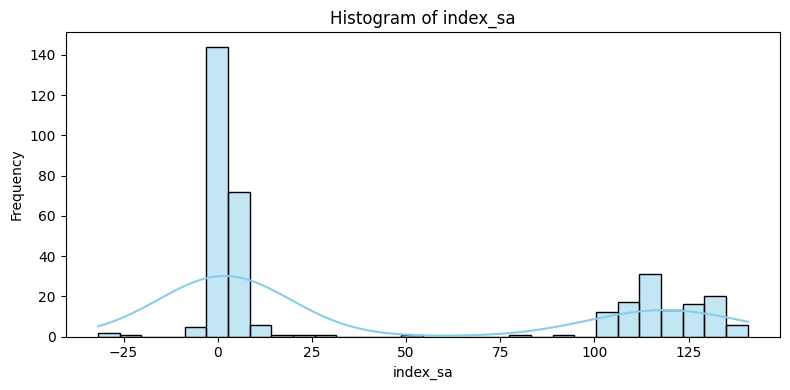

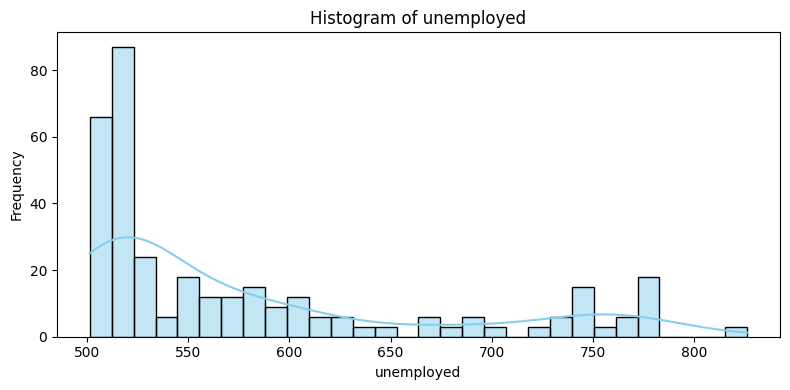

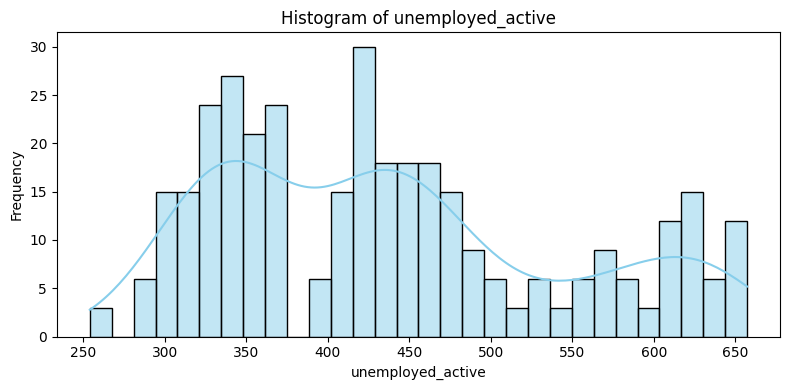

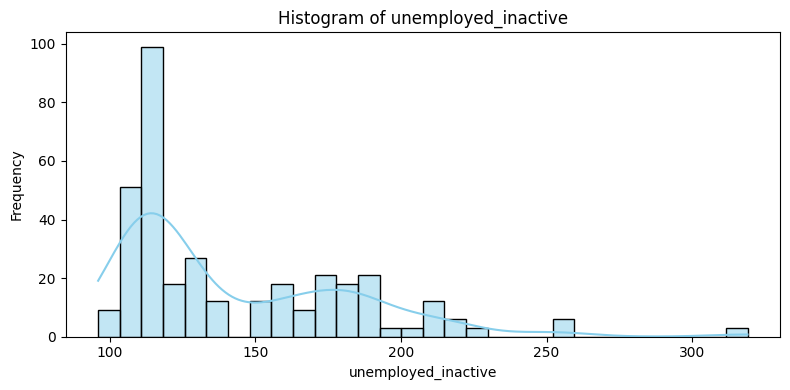

In [ ]:
selected_columns = ['index_sa', 'unemployed', 'unemployed_active', 'unemployed_inactive']

for col in selected_columns:
  plt.figure(figsize=(8, 4))
  sns.histplot(dt[col].dropna(), kde=True, bins=30, color='skyblue')
  plt.title(f'Histogram of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.show()

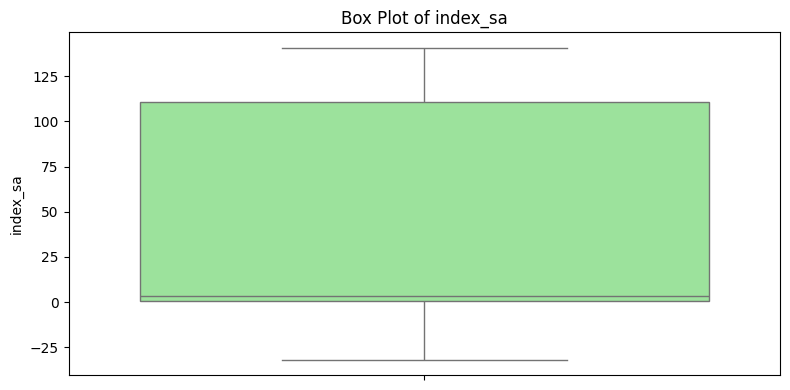

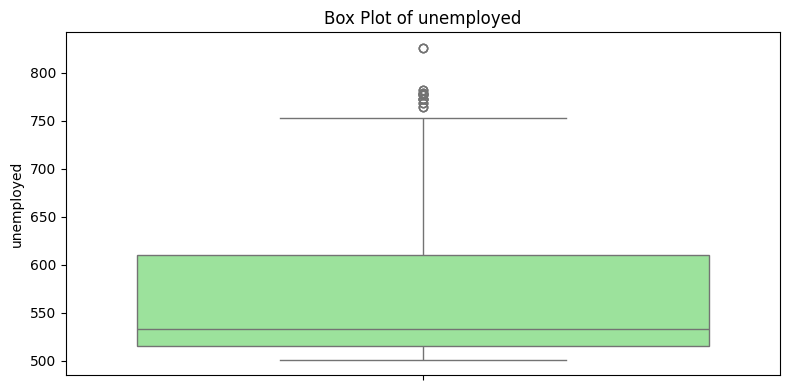

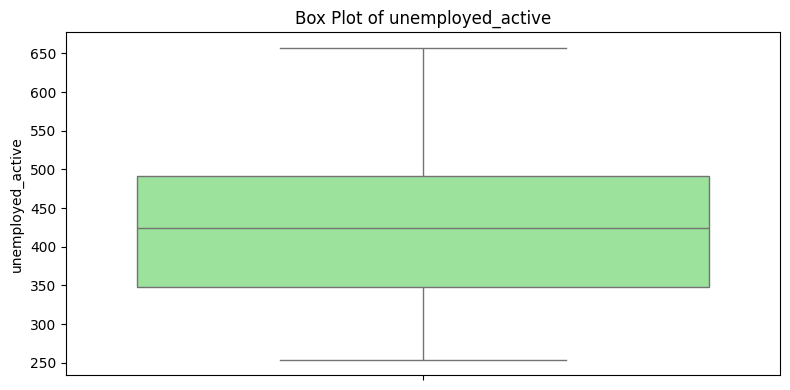

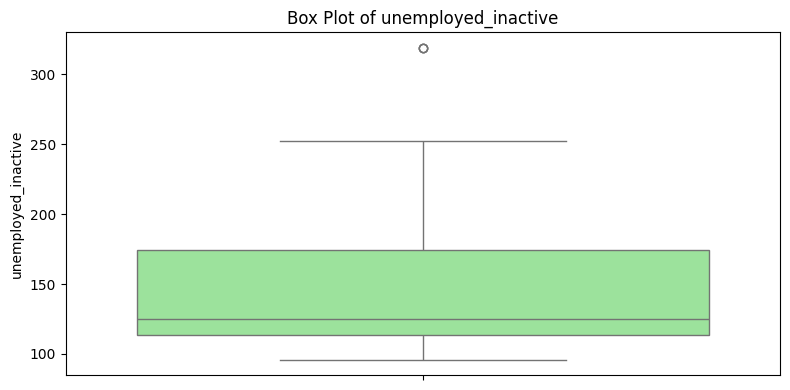

In [ ]:
for col in selected_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=dt[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# (2) Graphical Summaries

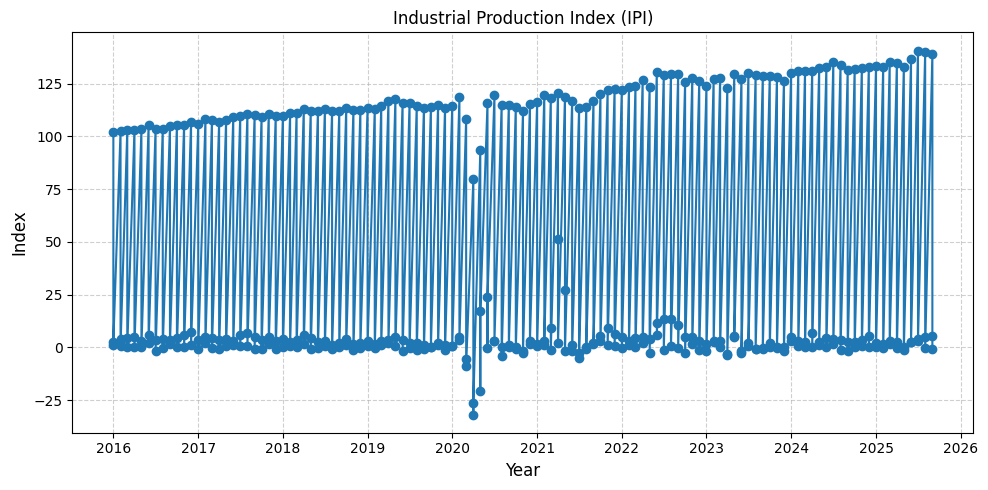

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(dt["index_sa"], marker='o')
plt.title("Industrial Production Index (IPI)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Index", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

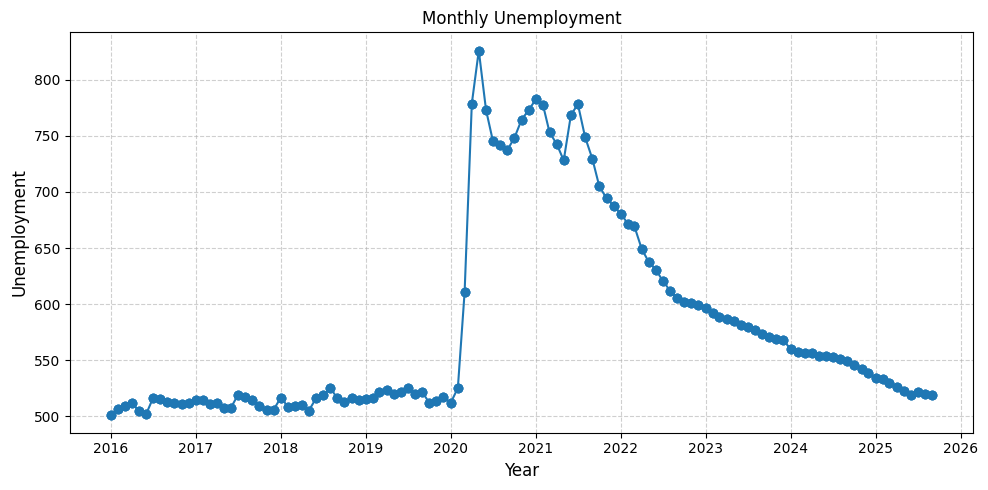

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(dt["unemployed"], marker='o')
plt.title("Monthly Unemployment", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Unemployment", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **ADDICTIVE DECOMPOSITION METHOD**

**IPI**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Use only IPI level series
dt = dt[dt["series"] == "abs"].copy()

dt = dt.sort_index()
dt = dt.asfreq("MS")

# Interpolate missing values
dt["index_sa"] = dt["index_sa"].interpolate()

In [ ]:
split = int(len(dt) * 0.9)

train = dt.iloc[:split]
test  = dt.iloc[split:]

y_train = train["index_sa"]
y_test  = test["index_sa"]

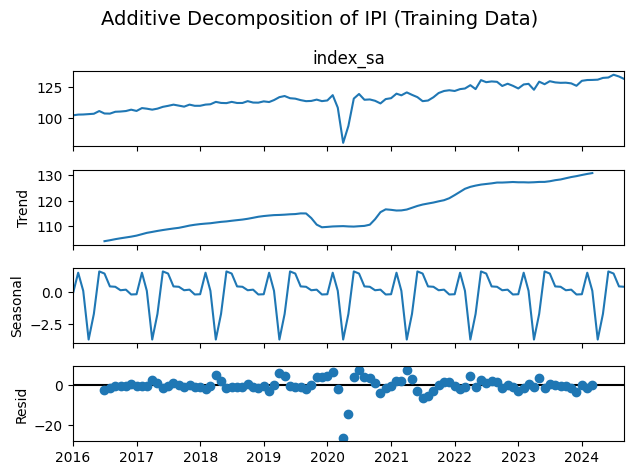

In [ ]:
add_decomp = seasonal_decompose(
    y_train,
    model="additive",
    period=12
)

add_decomp.plot()
plt.suptitle("Additive Decomposition of IPI (Training Data)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
trend = add_decomp.trend
seasonal = add_decomp.seasonal

seasonal_forecast = np.tile(
    seasonal[-12:],
    int(np.ceil(len(test) / 12))
)[:len(test)]

trend_forecast = np.repeat(trend.dropna().iloc[-1], len(test))

# Additive forecast
add_forecast = trend_forecast + seasonal_forecast

add_forecast = pd.Series(
    add_forecast,
    index=y_test.index
)

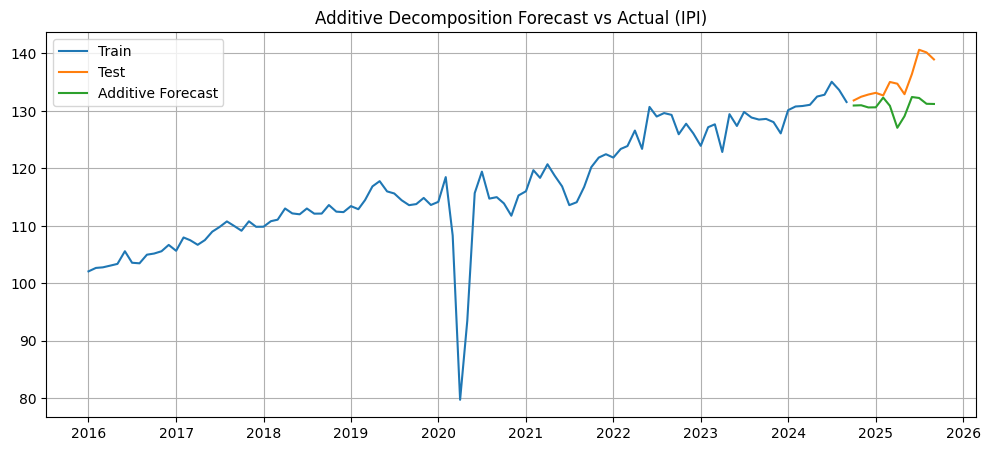

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.plot(add_forecast, label="Additive Forecast")
plt.title("Additive Decomposition Forecast vs Actual (IPI)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
add_mae = mean_absolute_error(y_test, add_forecast)
add_rmse = np.sqrt(mean_squared_error(y_test, add_forecast))
add_mape = np.mean(np.abs((y_test - add_forecast) / y_test)) * 100

print("Additive Decomposition Accuracy")
print("MAE :", add_mae)
print("RMSE:", add_rmse)
print("MAPE:", add_mape)

Additive Decomposition Accuracy
MAE : 4.351499999999979
RMSE: 5.254078227244371
MAPE: 3.178404413262379


**UNEMPLOYMENT**

In [ ]:
dt = dt.asfreq("MS")

# Interpolate missing values
dt["unemployed"] = dt["unemployed"].interpolate()

In [ ]:
split = int(len(dt) * 0.9)

train_u = dt.iloc[:split]
test_u  = dt.iloc[split:]

y_train_u = train_u["unemployed"]
y_test_u  = test_u["unemployed"]

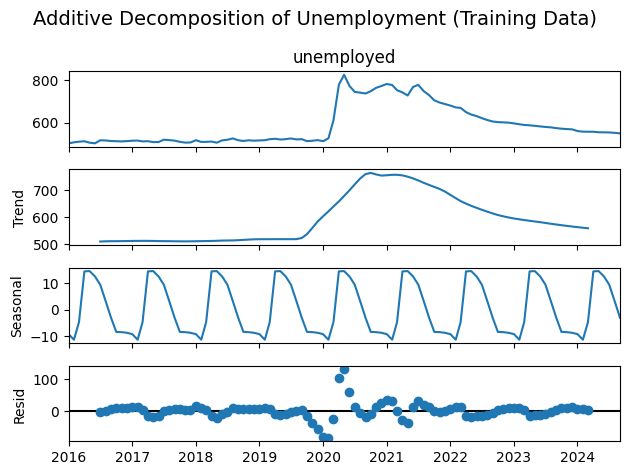

In [ ]:
add_decomp_u = seasonal_decompose(
    y_train_u,
    model="additive",
    period=12
)

add_decomp_u.plot()
plt.suptitle("Additive Decomposition of Unemployment (Training Data)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
trend_u = add_decomp_u.trend
seasonal_u = add_decomp_u.seasonal

seasonal_forecast_u = np.tile(
    seasonal_u[-12:],
    int(np.ceil(len(test_u) / 12))
)[:len(test_u)]

# Trend forecast
trend_forecast_u = np.repeat(trend_u.dropna().iloc[-1], len(test_u))

# Additive forecast
add_forecast_u = trend_forecast_u + seasonal_forecast_u

add_forecast_u = pd.Series(
    add_forecast_u,
    index=y_test_u.index
)

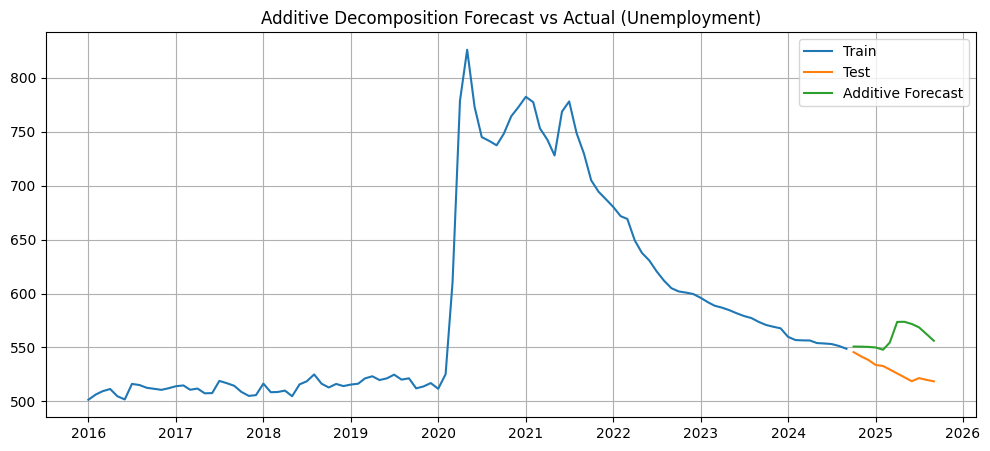

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_train_u, label="Train")
plt.plot(y_test_u, label="Test")
plt.plot(add_forecast_u, label="Additive Forecast")
plt.title("Additive Decomposition Forecast vs Actual (Unemployment)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
add_mae_u = mean_absolute_error(y_test_u, add_forecast_u)
add_rmse_u = np.sqrt(mean_squared_error(y_test_u, add_forecast_u))
add_mape_u = np.mean(np.abs((y_test_u - add_forecast_u) / y_test_u)) * 100

print("Additive Decomposition Accuracy (Unemployment)")
print("MAE :", add_mae_u)
print("RMSE:", add_rmse_u)
print("MAPE:", add_mape_u)


Additive Decomposition Accuracy (Unemployment)
MAE : 30.17083333333336
RMSE: 34.829828402346834
MAPE: 5.755041463577832


# **MULTIPLICATIVE DECOMPOSITION METHOD**

**IPI**

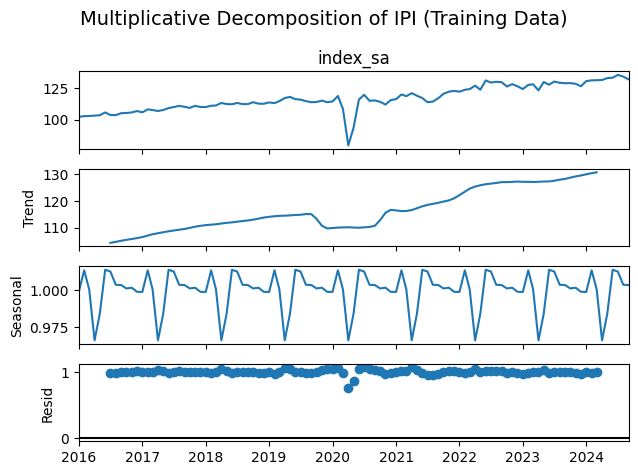

In [ ]:
mul_decomp = seasonal_decompose(
    y_train,
    model="multiplicative",
    period=12
)

mul_decomp.plot()
plt.suptitle("Multiplicative Decomposition of IPI (Training Data)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
trend_m = mul_decomp.trend
seasonal_m = mul_decomp.seasonal

seasonal_forecast_m = np.tile(
    seasonal_m[-12:],
    int(np.ceil(len(test) / 12))
)[:len(test)]

trend_forecast_m = np.repeat(trend_m.dropna().iloc[-1], len(test))

# Multiplicative forecast
mul_forecast = trend_forecast_m * seasonal_forecast_m

mul_forecast = pd.Series(
    mul_forecast,
    index=y_test.index
)

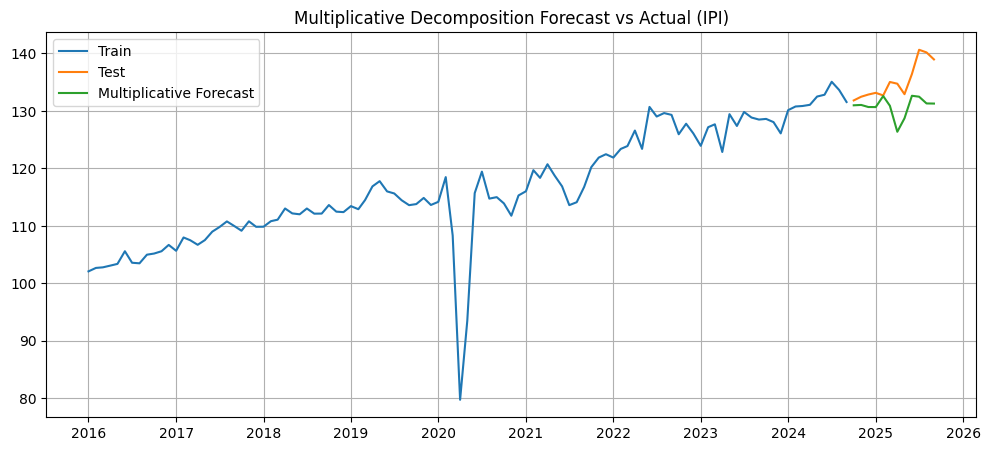

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.plot(mul_forecast, label="Multiplicative Forecast")
plt.title("Multiplicative Decomposition Forecast vs Actual (IPI)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
mul_mae = mean_absolute_error(y_test, mul_forecast)
mul_rmse = np.sqrt(mean_squared_error(y_test, mul_forecast))
mul_mape = np.mean(np.abs((y_test - mul_forecast) / y_test)) * 100

print("Multiplicative Decomposition Accuracy")
print("MAE :", mul_mae)
print("RMSE:", mul_rmse)
print("MAPE:", mul_mape)

Multiplicative Decomposition Accuracy
MAE : 4.351499999999983
RMSE: 5.297619026303447
MAPE: 3.1792674745789986


**UNEMPLOYMENT**

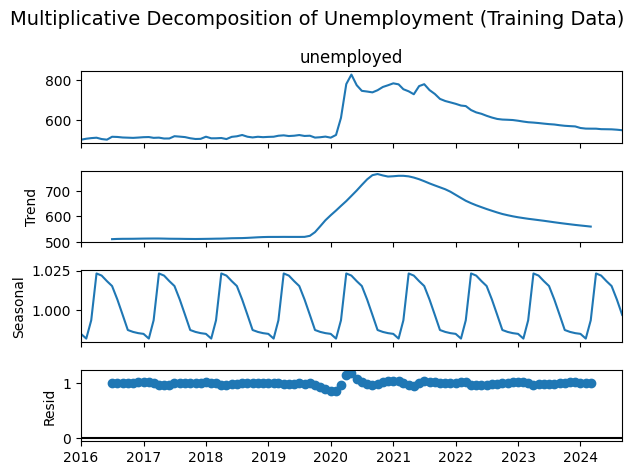

In [ ]:
mul_decomp_u = seasonal_decompose(
    y_train_u,
    model="multiplicative",
    period=12
)

mul_decomp_u.plot()
plt.suptitle("Multiplicative Decomposition of Unemployment (Training Data)", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
trend_um = mul_decomp_u.trend
seasonal_um = mul_decomp_u.seasonal

seasonal_forecast_um = np.tile(
    seasonal_um[-12:],
    int(np.ceil(len(test_u) / 12))
)[:len(test_u)]

# Trend forecast
trend_forecast_um = np.repeat(trend_um.dropna().iloc[-1], len(test_u))

# Multiplicative forecast
mul_forecast_u = trend_forecast_um * seasonal_forecast_um

mul_forecast_u = pd.Series(
    mul_forecast_u,
    index=y_test_u.index
)


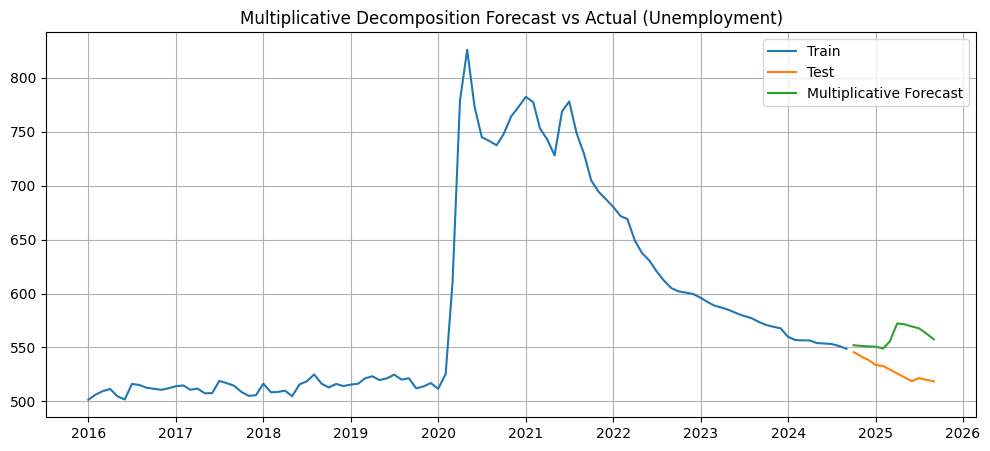

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_train_u, label="Train")
plt.plot(y_test_u, label="Test")
plt.plot(mul_forecast_u, label="Multiplicative Forecast")
plt.title("Multiplicative Decomposition Forecast vs Actual (Unemployment)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
mul_mae_u = mean_absolute_error(y_test_u, mul_forecast_u)
mul_rmse_u = np.sqrt(mean_squared_error(y_test_u, mul_forecast_u))
mul_mape_u = np.mean(np.abs((y_test_u - mul_forecast_u) / y_test_u)) * 100

print("Multiplicative Decomposition Accuracy (Unemployment)")
print("MAE :", mul_mae_u)
print("RMSE:", mul_rmse_u)
print("MAPE:", mul_mape_u)

Multiplicative Decomposition Accuracy (Unemployment)
MAE : 30.17083333333335
RMSE: 34.335987332337794
MAPE: 5.752804081260901


# **Double Exponential Smoothing Method**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import Holt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
dt.head()

,series,index,index_sa,unemployed,unemployed_active,unemployed_active_3mo,unemployed_active_6mo,unemployed_active_12mo,unemployed_active_long,unemployed_inactive
date,,,,,,,,,,
2016-01-01,abs,104.303,102.1,501.5,361.9,180.3,110.0,36.0,35.6,139.7
2016-02-01,abs,94.629,102.7,506.4,254.0,115.8,83.7,34.9,19.6,252.4
2016-03-01,abs,104.343,102.8,509.5,332.8,176.8,92.9,44.8,18.3,176.7
2016-04-01,abs,99.762,103.1,511.5,328.0,170.6,93.3,43.9,20.2,183.4
2016-05-01,abs,103.588,103.4,504.8,297.3,153.6,92.5,37.6,13.6,207.6


In [ ]:
# Filter for absolute series and interpolate if needed
dt_ipi = dt[dt["series"] == "abs"].copy()
dt_ipi = dt_ipi.asfreq("MS")
dt_ipi["index_sa"] = dt_ipi["index_sa"].interpolate()

In [ ]:
# Split IPI Data
split = int(len(dt_ipi) * 0.9)
train = dt_ipi.iloc[:split]
test  = dt_ipi.iloc[split:]

y_train = train["index_sa"]
y_test  = test["index_sa"]

In [ ]:
dt_u = dt.copy()
dt_u = dt_u[dt_u["series"] == "abs"]
dt_u = dt_u.asfreq("MS")
dt_u["unemployed"] = dt_u["unemployed"].interpolate()

# Split Unemployment Data
split_u = int(len(dt_u) * 0.9)
train_u = dt_u.iloc[:split_u]
test_u  = dt_u.iloc[split_u:]

y_train_u = train_u["unemployed"]
y_test_u  = test_u["unemployed"]

# IPI

In [ ]:
from statsmodels.tsa.holtwinters import Holt

# Initialize and Fit Holt's Model
holt_model = Holt(y_train, initialization_method='estimated')
holt_fit = holt_model.fit(optimized=True)

In [ ]:
# Forecast
holt_forecast = holt_fit.forecast(len(test))
holt_forecast.index = y_test.index  # Align dates

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate Metrics
holt_mae = mean_absolute_error(y_test, holt_forecast)
holt_rmse = np.sqrt(mean_squared_error(y_test, holt_forecast))
holt_mape = np.mean(np.abs((y_test - holt_forecast) / y_test)) * 100

print(f"Holt's Method Accuracy (IPI):")
print(f"MAE:  {holt_mae:.4f}")
print(f"RMSE: {holt_rmse:.4f}")
print(f"MAPE: {holt_mape:.2f}%")

Holt's Method Accuracy (IPI):
MAE:  1.9611
RMSE: 2.8433
MAPE: 1.42%


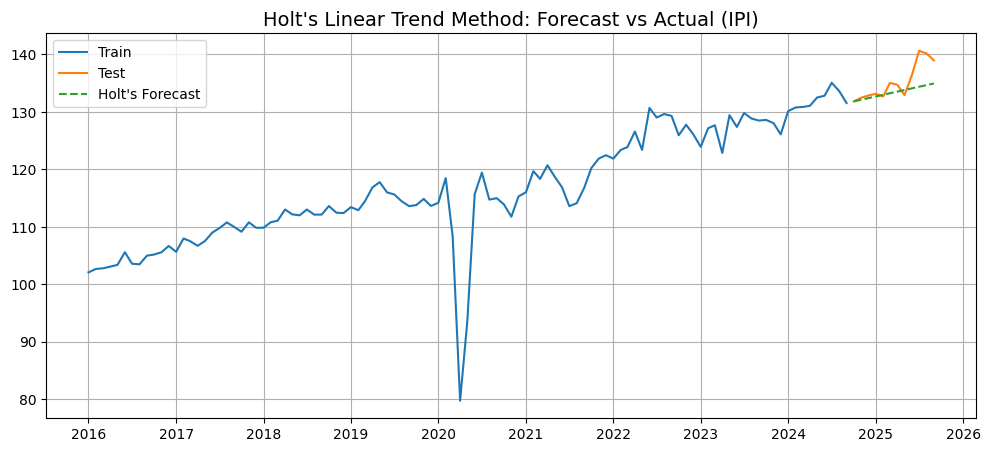

In [ ]:
# Plotting
plt.figure(figsize=(12,5))
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.plot(holt_forecast, label="Holt's Forecast", linestyle='--')
plt.title("Holt's Linear Trend Method: Forecast vs Actual (IPI)", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Unemployment

In [ ]:
# Initialize and Fit Holt's Model
holt_model_u = Holt(y_train_u, initialization_method='estimated')
holt_fit_u = holt_model_u.fit(optimized=True)

In [ ]:
# Forecast
holt_forecast_u = holt_fit_u.forecast(len(test_u))
holt_forecast_u.index = y_test_u.index  # Align dates

In [ ]:
# Calculate Metrics
holt_mae_u = mean_absolute_error(y_test_u, holt_forecast_u)
holt_rmse_u = np.sqrt(mean_squared_error(y_test_u, holt_forecast_u))
holt_mape_u = np.mean(np.abs((y_test_u - holt_forecast_u) / y_test_u)) * 100

print(f"Holt's Method Accuracy (Unemployment):")
print(f"MAE:  {holt_mae_u:.4f}")
print(f"RMSE: {holt_rmse_u:.4f}")
print(f"MAPE: {holt_mape_u:.2f}%")

Holt's Method Accuracy (Unemployment):
MAE:  2.9500
RMSE: 3.5786
MAPE: 0.56%


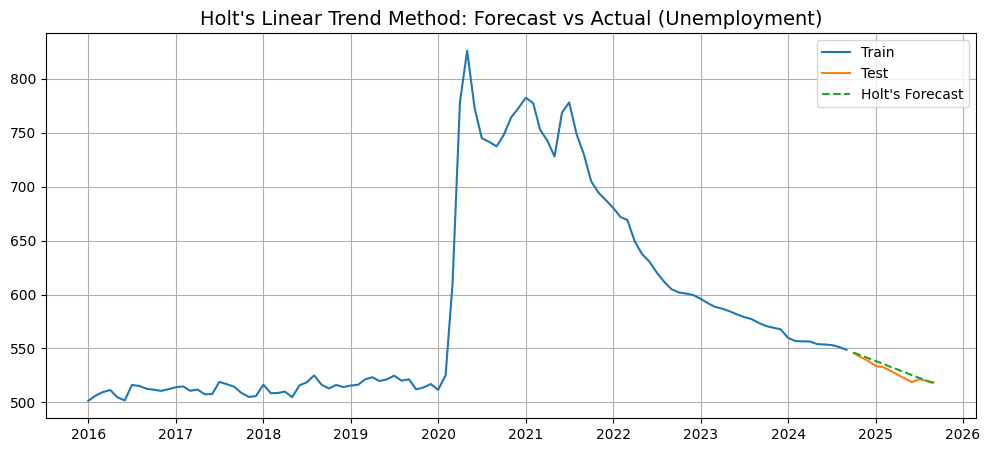

In [ ]:
# Plotting
plt.figure(figsize=(12,5))
plt.plot(y_train_u, label="Train")
plt.plot(y_test_u, label="Test")
plt.plot(holt_forecast_u, label="Holt's Forecast", linestyle='--')
plt.title("Holt's Linear Trend Method: Forecast vs Actual (Unemployment)", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Box-Jenkins Model




# IPI

In [ ]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/content/ipi.csv')

# Filter for series='abs'
data = data[data['series'] == 'abs']

# Select 'date' and 'index' columns
data = data[['date', 'index']]
data = data.set_index("date")

data.index = pd.to_datetime(data.index)

start_date = '2016-01-01'
end_date = '2025-09-01'

data = data.loc[start_date:end_date]
data

,index
date,
2016-01-01,104.303
2016-02-01,94.629
2016-03-01,104.343
2016-04-01,99.762
2016-05-01,103.588
...,...
2025-05-01,128.492
2025-06-01,138.097
2025-07-01,137.747


In [ ]:
data.head()

,index
date,
2016-01-01,104.303
2016-02-01,94.629
2016-03-01,104.343
2016-04-01,99.762
2016-05-01,103.588


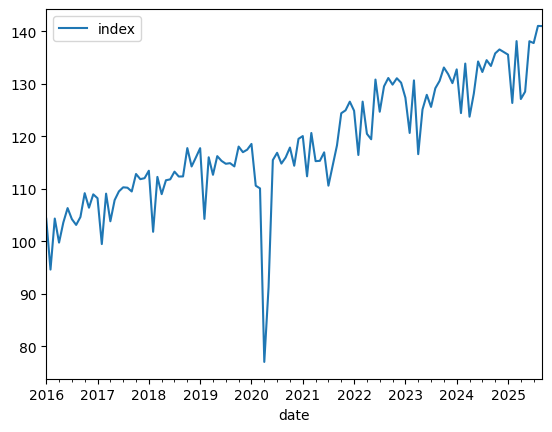

In [ ]:
#plot the time series data
from matplotlib import pyplot
data.plot()
pyplot.show()

In [ ]:
#split data into training and testing using 90:10
split_point = int(len(data) * 0.90)

df = data.iloc[:split_point]# in-sample data (training data)
test  = data.iloc[split_point:] #out-sample data (testing data)

print("Total observations:", len(data))
print("Training:", len(df))
print("Testing:", len(test))

Total observations: 117
Training: 105
Testing: 12


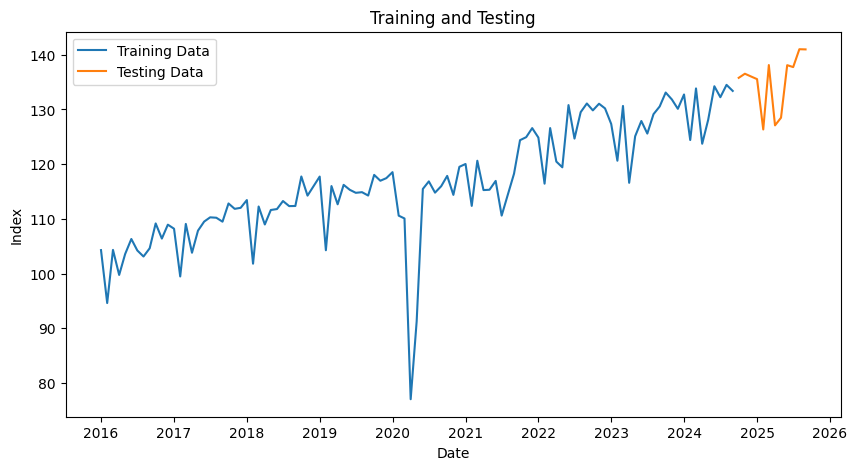

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df, label="Training Data")
plt.plot(test, label="Testing Data")
plt.title("Training and Testing")
plt.xlabel("Date")
plt.ylabel("Index")
plt.legend()
plt.show()

In [ ]:
# Box-Cox to check stationarity in variance
from scipy.stats import boxcox

transformed_data, lambda_value = boxcox(df['index'])

print(f"Estimated lambda: {lambda_value}")

Estimated lambda: 2.3940031121917085


In [ ]:
# Box-Cox to check stationarity in variance
from scipy.stats import boxcox

transformed_data2, lambda_value2 = boxcox(transformed_data)

print(f"Estimated lambda: {lambda_value2}")

Estimated lambda: 1.0000002918543296


In [ ]:
in_sample_transformed = pd.DataFrame(transformed_data,
                                     index=df.index,
                                     columns=['index'])


In [ ]:
# Box-Cox to check stationarity in mean

from statsmodels.tsa.stattools import adfuller

adfuller(in_sample_transformed)

(np.float64(0.26669140694113164),
 np.float64(0.9757636251029282),
 13,
 91,
 {'1%': np.float64(-3.50434289821397),
  '5%': np.float64(-2.8938659630479413),
  '10%': np.float64(-2.5840147047458037)},
 np.float64(1748.0387740284095))

In [ ]:
# Box-Cox to check stationarity in mean

from statsmodels.tsa.stattools import adfuller

print("p-value:", adfuller(in_sample_transformed.dropna())[1])

p-value: 0.9757636251029282


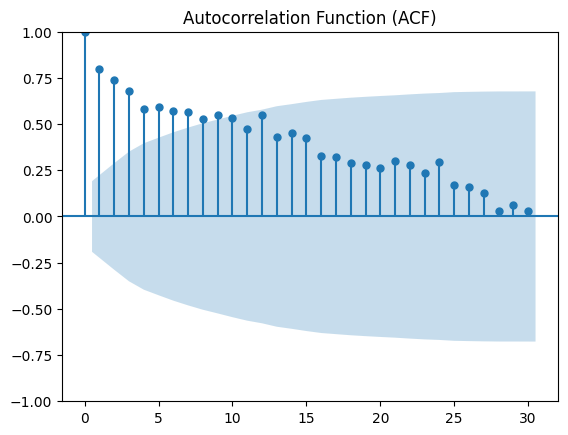

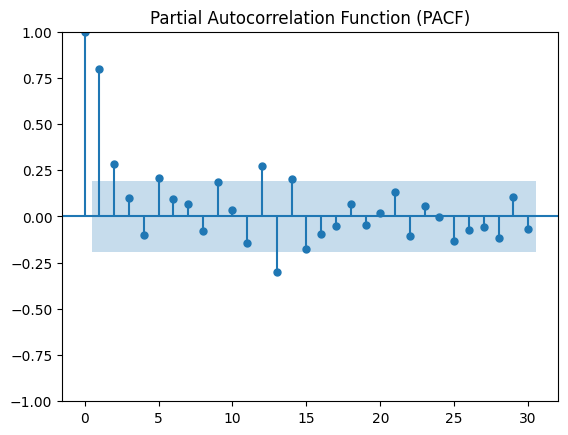

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

# Plot ACF
plot_acf(in_sample_transformed, lags=30, title="Autocorrelation Function (ACF)")
plt.show()

# Plot PACF
plot_pacf(in_sample_transformed, lags=30, title="Partial Autocorrelation Function (PACF)")
plt.show()

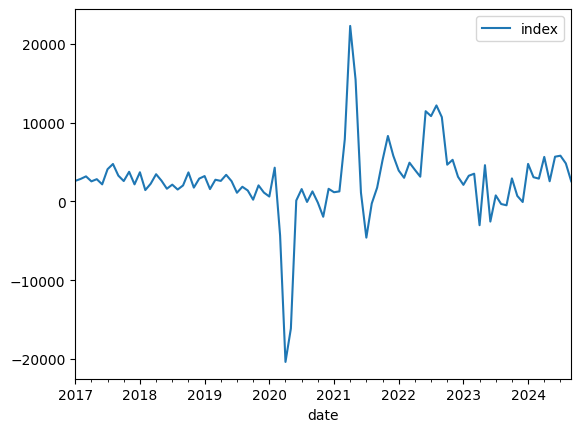

In [ ]:
#first seasonal differencing(to remove the seasonality of the data) : D=1
in_sample_transformed_diffseasonal = in_sample_transformed.diff(12).dropna()
from matplotlib import pyplot
in_sample_transformed_diffseasonal.plot()
pyplot.show()

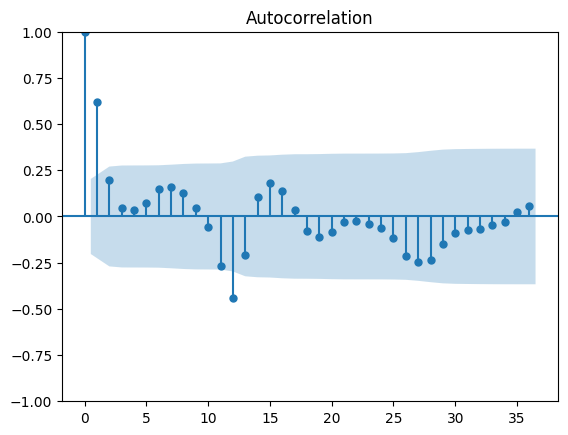

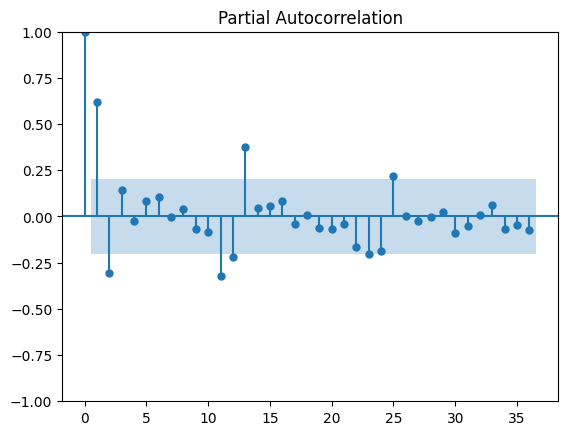

In [ ]:
# Step 1: Create the variable (assuming a seasonal period of 12)
in_sample_transformed_diffseasonal = in_sample_transformed.diff(periods=12).dropna()

# Step 2: Plot acf and pacf for first seasonal differencing
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt # Import plt if not already done

# Plot ACF
plot_acf(in_sample_transformed_diffseasonal, lags=36)

# Plot PACF
plot_pacf(in_sample_transformed_diffseasonal, lags=36)

plt.show()

In [ ]:
#to remove trends and make the time series stationary in mean.
# First differencing non-seasonal part
in_sample_transformed_diff = in_sample_transformed_diffseasonal.diff(1).dropna()

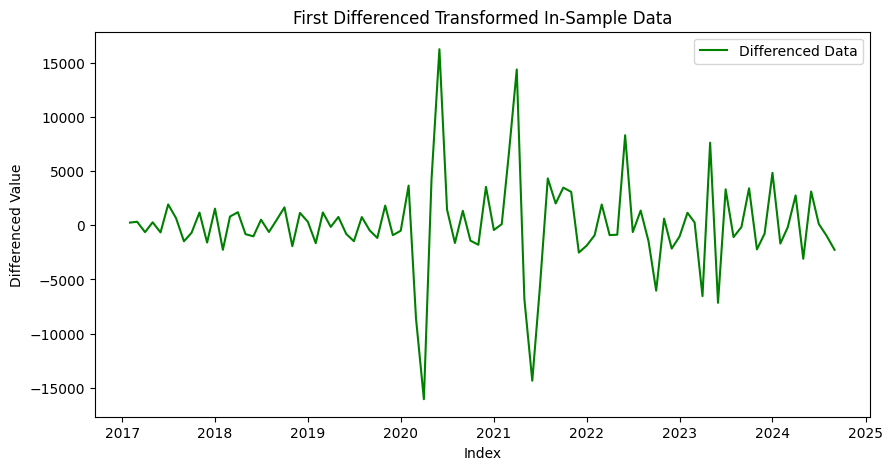

In [ ]:
# Plot the differenced data
plt.figure(figsize=(10, 5))
plt.plot(in_sample_transformed_diff, label='Differenced Data', color='green')
plt.title('First Differenced Transformed In-Sample Data')
plt.xlabel('Index')
plt.ylabel('Differenced Value')
plt.legend()
plt.show()

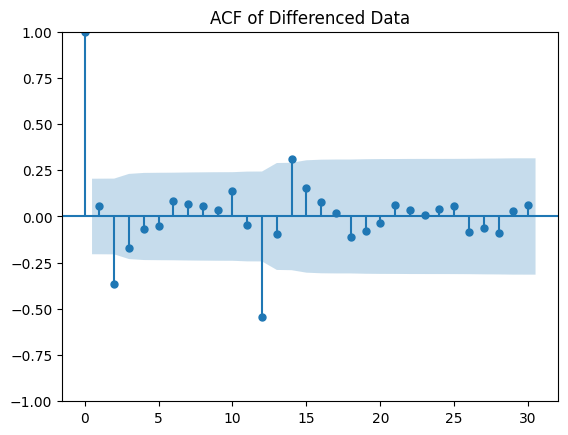

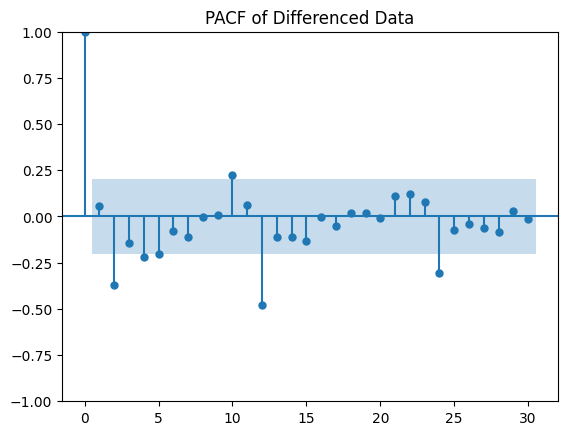

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF and PACF for differenced data
plot_acf(in_sample_transformed_diff, lags=30)
plt.title('ACF of Differenced Data')
plt.show()

plot_pacf(in_sample_transformed_diff, lags=30)
plt.title('PACF of Differenced Data')
plt.show()


In [ ]:
print("p-value:", adfuller(in_sample_transformed_diff.dropna())[1])

p-value: 0.0012837279698018301


In [ ]:
!pip install pmdarima

In [ ]:
#use auto.arima for the best model (looking at the smallest AIC value)
from pmdarima.arima import auto_arima
best_model = auto_arima(in_sample_transformed, start_p=1, start_q=1,
                           max_p=2, max_q=2, m=12,
                           start_P=0,start_Q=0,max_P=2,max_Q=3, seasonal=True,
                           d=1, D=1, trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
print(best_model.aic())
print(best_model.bic())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1796.374, Time=1.33 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1799.902, Time=0.14 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1783.159, Time=0.51 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1767.528, Time=1.80 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1801.634, Time=0.16 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1778.142, Time=0.59 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=1769.528, Time=2.32 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1779.472, Time=1.24 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=5.64 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1765.786, Time=0.73 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=1767.786, Time=2.35 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=1767.883, Time=1.12 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1778.266, Time=0.41 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=1769.685, Time=2.68 sec
 ARIMA(1,1,0)(0,1,1)[12]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_model = SARIMAX(in_sample_transformed, order=(0,1,2), seasonal_order=(0,1,1,12))
best_model = best_model.fit(disp=False)
print(best_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                                index   No. Observations:                  105
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -875.433
Date:                              Fri, 16 Jan 2026   AIC                           1758.867
Time:                                      10:08:26   BIC                           1768.954
Sample:                                  01-01-2016   HQIC                          1762.938
                                       - 09-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0295      0.079     -0.374      0.708      -0.184       0.125
ma.L2         -0.32

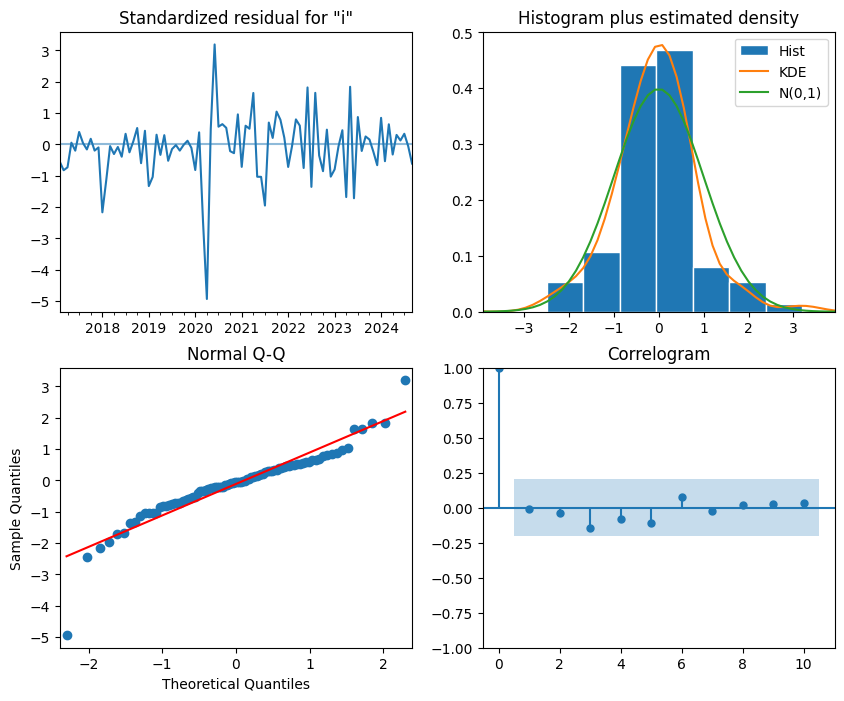

In [ ]:
#visualise the diagnostic checking
best_model.plot_diagnostics(figsize=(10,8));

In [ ]:
# number of months in your testing set
steps = len(test)

# forecast based on Box-Cox transformed SARIMAX model
forecast_transformed = best_model.forecast(steps=steps)
forecast_transformed


,predicted_mean
2024-10-01,53079.652170
2024-11-01,53201.097702
2024-12-01,53059.735846
2025-01-01,53558.024498
2025-02-01,46981.905183
2025-03-01,54495.215932
2025-04-01,45989.387635
2025-05-01,49491.703594
2025-06-01,54549.107272
2025-07-01,52246.957621


In [ ]:
from scipy.special import inv_boxcox

forecast = inv_boxcox(forecast_transformed, lambda_value)
forecast = pd.Series(forecast, index=test.index)
forecast


,predicted_mean
date,
2024-10-01,135.524359
2024-11-01,135.653794
2024-12-01,135.503116
2025-01-01,136.033211
2025-02-01,128.789353
2025-03-01,137.022499
2025-04-01,127.645812
2025-05-01,131.619695
2025-06-01,137.079083


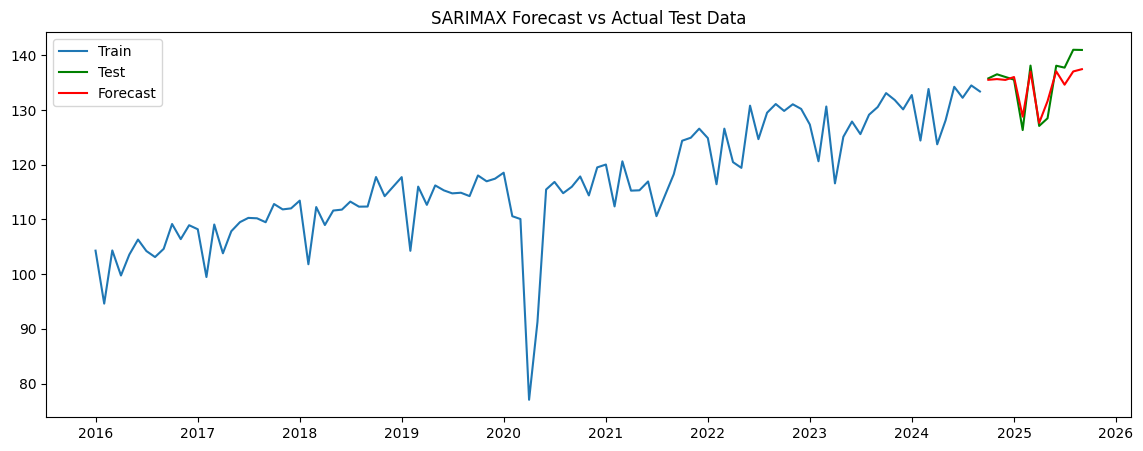

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['index'], label='Train')
plt.plot(test['index'], label='Test', color='green')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.title("SARIMAX Forecast vs Actual Test Data")
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test['index']
predicted = forecast

# MAE
mae = mean_absolute_error(actual, predicted)

# RMSE
rmse = np.sqrt(mean_squared_error(actual, predicted))

# MAPE
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)


MAE  : 1.7490135683039452
RMSE : 2.1871122616827225
MAPE : 1.2903355240067926


# UNEMPLOYMENT

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Load the dataset
data = pd.read_csv('/content/lfs_month_duration.csv')

# --- FIX: Convert date column to datetime objects ---
data['date'] = pd.to_datetime(data['date'])

# Select 'date' and 'unemployed' columns
data = data[['date', 'unemployed']]
data = data.set_index("date")
data

,unemployed
date,
2016-01-01,501.5
2016-02-01,506.4
2016-03-01,509.5
2016-04-01,511.5
2016-05-01,504.8
...,...
2025-05-01,522.4
2025-06-01,518.7
2025-07-01,521.6


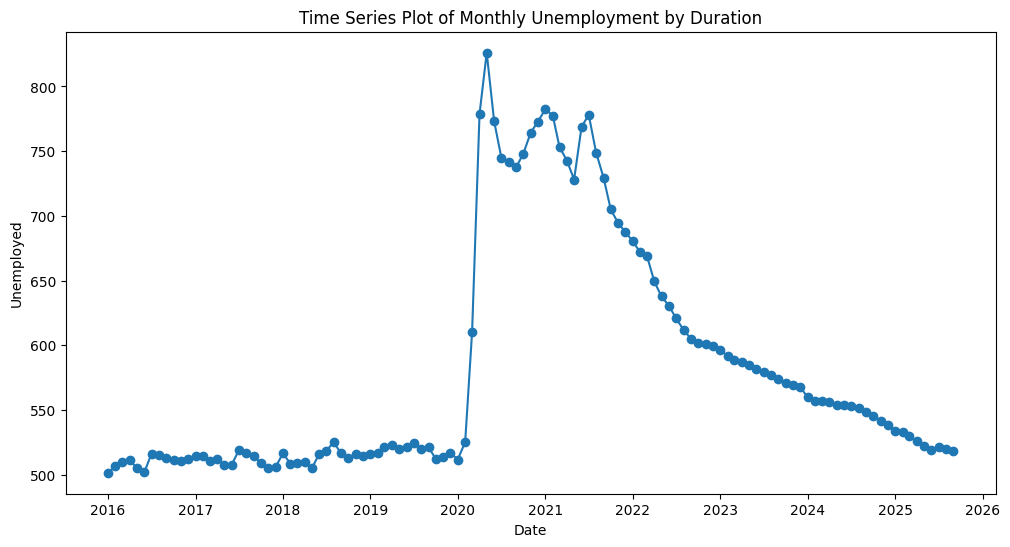

In [ ]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['unemployed'], marker='o', linestyle='-')
plt.title('Time Series Plot of Monthly Unemployment by Duration')
plt.xlabel('Date')
plt.ylabel('Unemployed')
plt.grid(False)
plt.show()

In [ ]:
data.count()

,0
unemployed,117


In [ ]:
# Split the data into in-sample and out-sample
# Split the data into in-sample and out-sample
in_sample = data[(data.index >= '2016-01-01') & (data.index <= '2024-09-01')]
out_sample = data[(data.index >= '2024-10-01') & (data.index <= '2025-09-01')]

In [ ]:
print(in_sample.count())
print(out_sample.count())

unemployed    105
dtype: int64
unemployed    12
dtype: int64


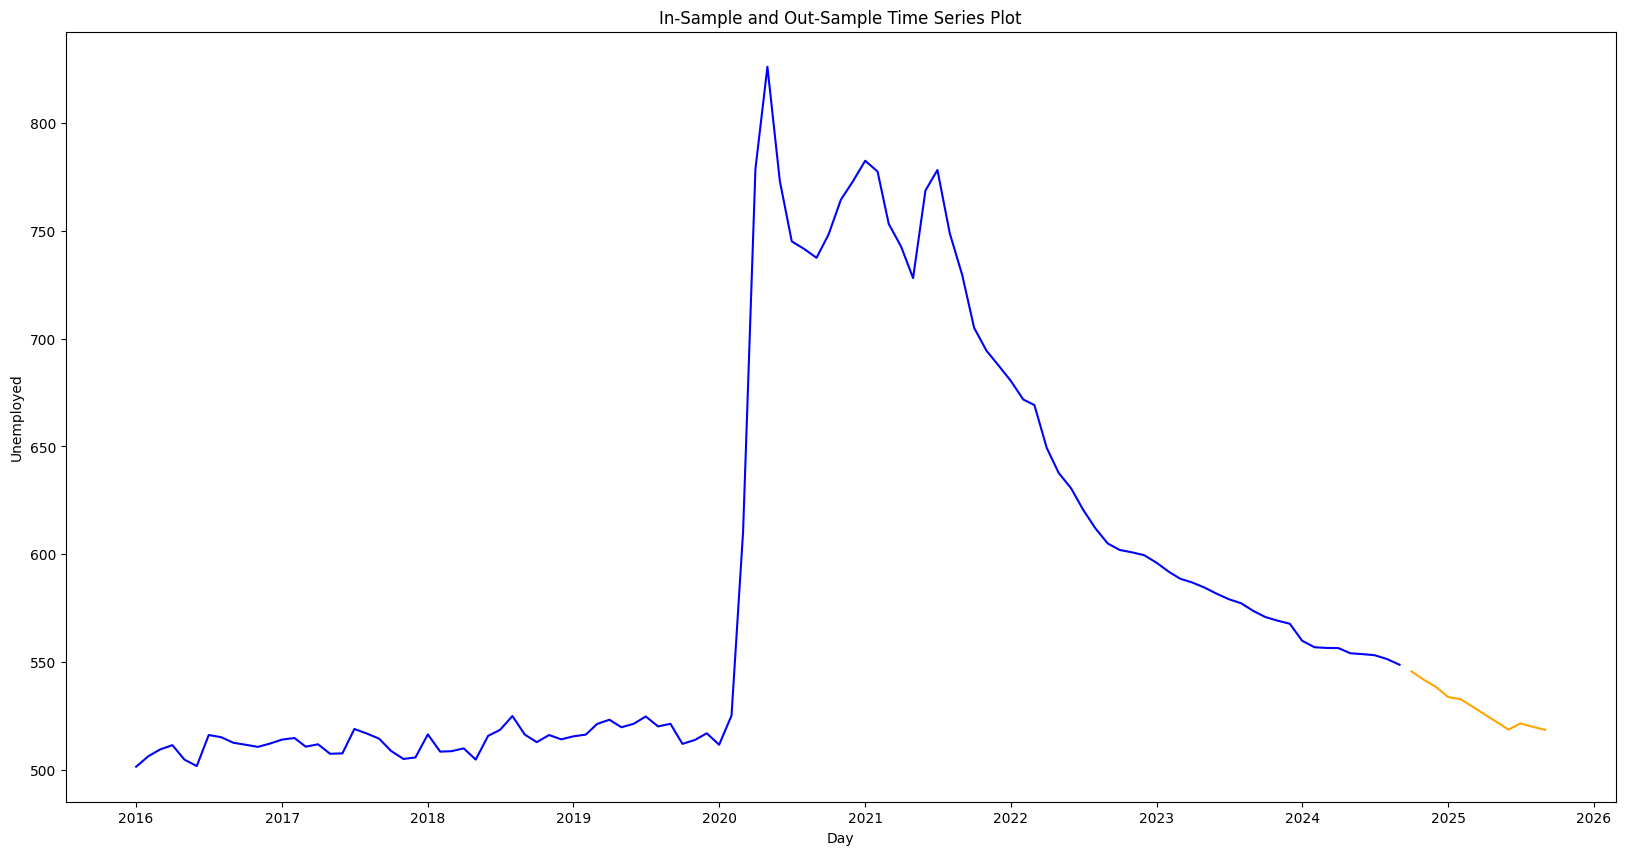

In [ ]:
#plot the in-sample and out-sample data
from matplotlib import pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(in_sample['unemployed'], label='In-Sample', color='blue')
plt.plot(out_sample['unemployed'], label='Out-Sample', color='orange')
plt.title('In-Sample and Out-Sample Time Series Plot')
plt.xlabel('Day')
plt.ylabel('Unemployed')
plt.grid(False)
plt.show()

In [ ]:
# Box-Cox to check stationarity in variance
from scipy.stats import boxcox

transformed_data, lambda_value = boxcox(in_sample['unemployed'])

print(f"Estimated lambda: {lambda_value}")

Estimated lambda: -4.682717687008023


In [ ]:
transformed_data

array([0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512, 0.2135512,
       0.2135512, 0.2135512, 0.2135512, 0.2135512, 

In [ ]:
# Box-Cox to check stationarity in variance
from scipy.stats import boxcox

transformed_data2, lambda_value2 = boxcox(transformed_data)

print(f"Estimated lambda: {lambda_value2}")

Estimated lambda: -1.2756345344161288


In [ ]:
in_sample_transformed = pd.DataFrame(transformed_data,
                                     index=in_sample.index,
                                     columns=['unemployed'])
in_sample_transformed

,unemployed
date,
2016-01-01,0.213551
2016-02-01,0.213551
2016-03-01,0.213551
2016-04-01,0.213551
2016-05-01,0.213551
...,...
2024-05-01,0.213551
2024-06-01,0.213551
2024-07-01,0.213551


In [ ]:
#stationary test using ADF test (to check stationarity in mean)
from statsmodels.tsa.stattools import adfuller
print("p-value:", adfuller(in_sample_transformed.dropna())[1])

p-value: 0.5533883105638173


$H_0$: The time series is not-stationary\
$H_1$: The time series is stationary\
\
$p-value=0.5535$\
\
Since $(p-value=0.5535)>(\alpha=0.05)$ do not reject $H_0$.\
\
At $\alpha=0.05$, the time series is not stationary.

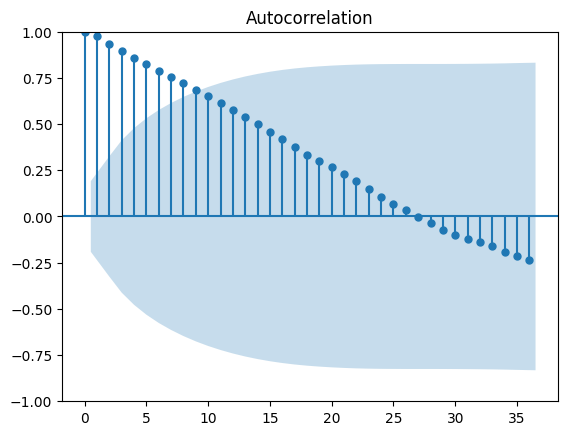

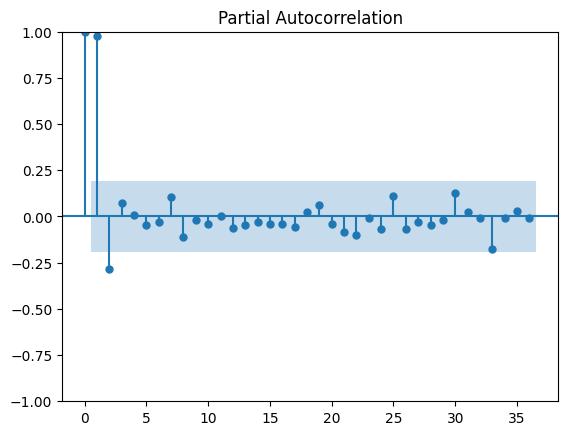

In [ ]:
#stationarity test in mean using ACF & PACF plot
from matplotlib import pyplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
plot_acf(in_sample_transformed,lags = 36),plot_pacf(in_sample_transformed, lags = 36)
pyplot.show()

In [ ]:
#to remove trends and make the time series stationary in mean.
# First differencing of the transformed training data

in_sample_transformed_diff = in_sample_transformed.diff().dropna()

In [ ]:
# Stationary test using ADF test after differencing
print("p-value after differencing:", adfuller(in_sample_transformed_diff.dropna())[1])

p-value after differencing: 5.371031731753205e-09


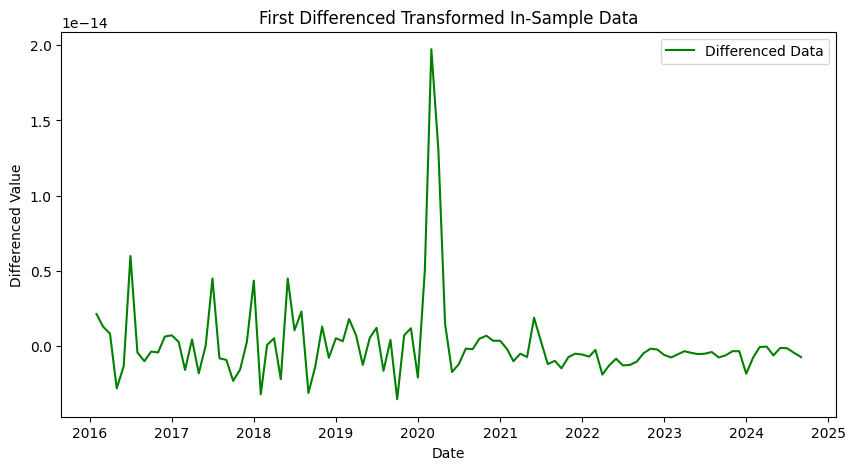

In [ ]:
# Plot the differenced data
plt.figure(figsize=(10, 5))
plt.plot(in_sample_transformed_diff, label='Differenced Data', color='green')
plt.title('First Differenced Transformed In-Sample Data')
plt.xlabel('Date')
plt.ylabel('Differenced Value')
plt.legend()
plt.show()

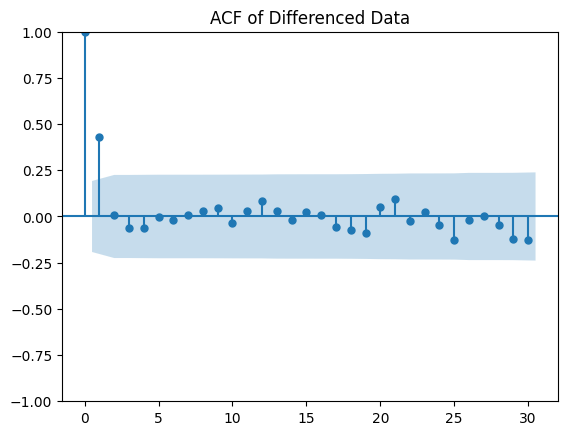

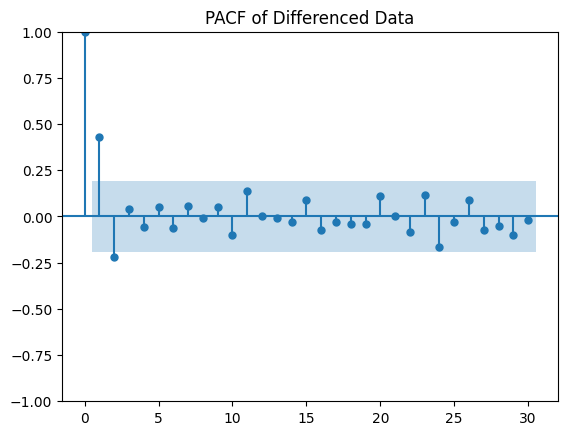

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF and PACF for differenced data
plot_acf(in_sample_transformed_diff, lags=30)
plt.title('ACF of Differenced Data')
plt.show()

plot_pacf(in_sample_transformed_diff, lags=30)
plt.title('PACF of Differenced Data')
plt.show()



In [ ]:
from statsmodels.tsa.arima.model import ARIMA

models = [(0,1,1),(1,1,0),(2,1,0),(1,1,1)]

for order in models:
    print(f"\n=== ARIMA{order} with trend='t' ===")
    model = ARIMA(in_sample_transformed, order=order, trend='t')
    result = model.fit()
    print(result.summary())


=== ARIMA(0, 1, 1) with trend='t' ===


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

                               SARIMAX Results                                
Dep. Variable:             unemployed   No. Observations:                  105
Model:                 ARIMA(0, 1, 1)   Log Likelihood                1090.651
Date:                Fri, 16 Jan 2026   AIC                          -2175.302
Time:                        10:08:32   BIC                          -2167.369
Sample:                    01-01-2016   HQIC                         -2172.088
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          1.601e-16   3.64e-26    4.4e+09      0.000     1.6e-16     1.6e-16
ma.L1          0.5326   5.63e-21   9.46e+19      0.000       0.533       0.533
sigma2          1e-10   1.95e-10      0.512      0.6

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             unemployed   No. Observations:                  105
Model:                 ARIMA(1, 1, 0)   Log Likelihood                1090.780
Date:                Fri, 16 Jan 2026   AIC                          -2175.559
Time:                        10:08:33   BIC                          -2167.626
Sample:                    01-01-2016   HQIC                         -2172.345
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          1.601e-16   4.12e-26   3.88e+09      0.000     1.6e-16     1.6e-16
ar.L1          0.4299   5.01e-21   8.58e+19      0.000       0.430       0.430
sigma2          1e-10   1.95e-10      0.512      0.6

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             unemployed   No. Observations:                  105
Model:                 ARIMA(2, 1, 0)   Log Likelihood                1090.674
Date:                Fri, 16 Jan 2026   AIC                          -2173.349
Time:                        10:08:33   BIC                          -2162.771
Sample:                    01-01-2016   HQIC                         -2169.064
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          1.601e-16   4.63e-26   3.46e+09      0.000     1.6e-16     1.6e-16
ar.L1          0.5238    4.5e-21   1.16e+20      0.000       0.524       0.524
ar.L2         -0.2192   1.03e-21  -2.13e+20      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# Fit ARIMA(0,1,1) model

model1 = ARIMA(in_sample_transformed, order=(0, 1, 1), trend="t")
model1_fit = model1.fit()

# Print the model summary
print(model1_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             unemployed   No. Observations:                  105
Model:                 ARIMA(0, 1, 1)   Log Likelihood                1090.651
Date:                Fri, 16 Jan 2026   AIC                          -2175.302
Time:                        10:08:34   BIC                          -2167.369
Sample:                    01-01-2016   HQIC                         -2172.088
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          1.601e-16   3.64e-26    4.4e+09      0.000     1.6e-16     1.6e-16
ma.L1          0.5326   5.63e-21   9.46e+19      0.000       0.533       0.533
sigma2          1e-10   1.95e-10      0.512      0.6

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Fit ARIMA(1,1,0) model

model2 = ARIMA(in_sample_transformed, order=(1, 1, 0), trend="t")
model2_fit = model2.fit()

# Print the model summary
print(model2_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             unemployed   No. Observations:                  105
Model:                 ARIMA(1, 1, 0)   Log Likelihood                1090.780
Date:                Fri, 16 Jan 2026   AIC                          -2175.559
Time:                        10:08:34   BIC                          -2167.626
Sample:                    01-01-2016   HQIC                         -2172.345
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          1.601e-16   4.12e-26   3.88e+09      0.000     1.6e-16     1.6e-16
ar.L1          0.4299   5.01e-21   8.58e+19      0.000       0.430       0.430
sigma2          1e-10   1.95e-10      0.512      0.6

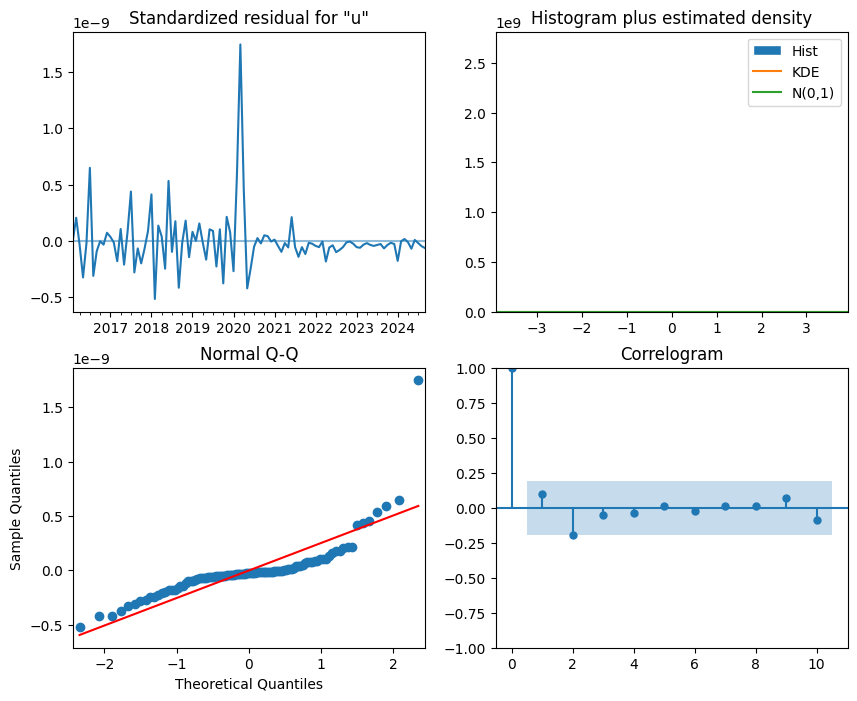

In [ ]:
model2_fit.plot_diagnostics(figsize=(10, 8))
plt.show()

In [ ]:
import pmdarima as pm

# auto ARIMA — automatically finds best (p,d,q)
model_auto = pm.auto_arima(in_sample_transformed,
                      seasonal=False,       # set to True if seasonal pattern
                      stepwise=True,         # fast stepwise search
                      trace=True,            # show all results
                      suppress_warnings=True,
                      max_p=5, max_q=5,      # limit search range
                      d=None,                # auto determine differencing
                      information_criterion='aic')

print(model_auto.summary())



Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-2169.316, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-2241.832, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-2236.870, Time=0.41 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-2175.302, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-2603.781, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-2173.424, Time=1.18 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.340 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  105
Model:               SARIMAX(0, 1, 0)   Log Likelihood                1302.890
Date:                Fri, 16 Jan 2026   AIC                          -2603.781
Time:                        10:08:41   BIC                          -2601.136
Sample:                    01-01-2016   HQIC                         -2602.710
    

<Figure size 600x400 with 0 Axes>

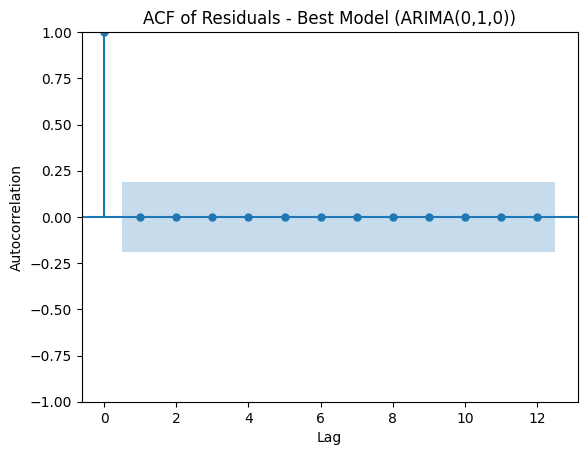

In [ ]:
# --- Plot ACF of residuals for the best model ---
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# get residuals from your fitted model
residuals = model_auto.resid()

# ACF plot
plt.figure(figsize=(6,4))
plot_acf(residuals, lags=12)
plt.title('ACF of Residuals - Best Model (ARIMA(0,1,0))')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()



In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)
print(lb_test)

     lb_stat  lb_pvalue
12  0.000641        1.0


In [ ]:
# Predict the testing data range
start = out_sample['unemployed'].index[0]  # Start index of testing data
end = out_sample['unemployed'].index[-1]   # End index of testing data

# Use the fitted model to predict
forecast_out_sample = model2_fit.predict(start=start, end=end)

forecast_out_sample

,predicted_mean
2024-10-01,0.213551
2024-11-01,0.213551
2024-12-01,0.213551
2025-01-01,0.213551
2025-02-01,0.213551
2025-03-01,0.213551
2025-04-01,0.213551
2025-05-01,0.213551
2025-06-01,0.213551
2025-07-01,0.213551


In [ ]:
from scipy.special import inv_boxcox

# Convert predicted values to original scale using inverse Box-Cox transformation
fcast1_out_sample = inv_boxcox(forecast_out_sample, lambda_value)

fcast1_out_sample

,predicted_mean
2024-10-01,547.903449
2024-11-01,547.816753
2024-12-01,548.164005
2025-01-01,548.687239
2025-02-01,549.301284
2025-03-01,549.742288
2025-04-01,550.363090
2025-05-01,550.987897
2025-06-01,551.616757
2025-07-01,552.159042


In [ ]:
fcast1_out_sample.count()

np.int64(12)

In [ ]:
#in-sample fitted values from model ARIMA (0,1,0)
fcast1_in_sample = model1_fit.fittedvalues
fcast1_in_sample

,0
date,
2016-01-01,1.601283e-16
2016-02-01,2.135512e-01
2016-03-01,2.135512e-01
2016-04-01,2.135512e-01
2016-05-01,2.135512e-01
...,...
2024-05-01,2.135512e-01
2024-06-01,2.135512e-01
2024-07-01,2.135512e-01


In [ ]:
# Convert predicted values to original scale using inverse Box-Cox transformation
fcast1_in_sample = inv_boxcox(fcast1_in_sample, lambda_value)

fcast1_in_sample

,0
date,
2016-01-01,1.000000
2016-02-01,501.902693
2016-03-01,502.219431
2016-04-01,511.579848
2016-05-01,511.932954
...,...
2024-05-01,557.085048
2024-06-01,553.161158
2024-07-01,554.637443


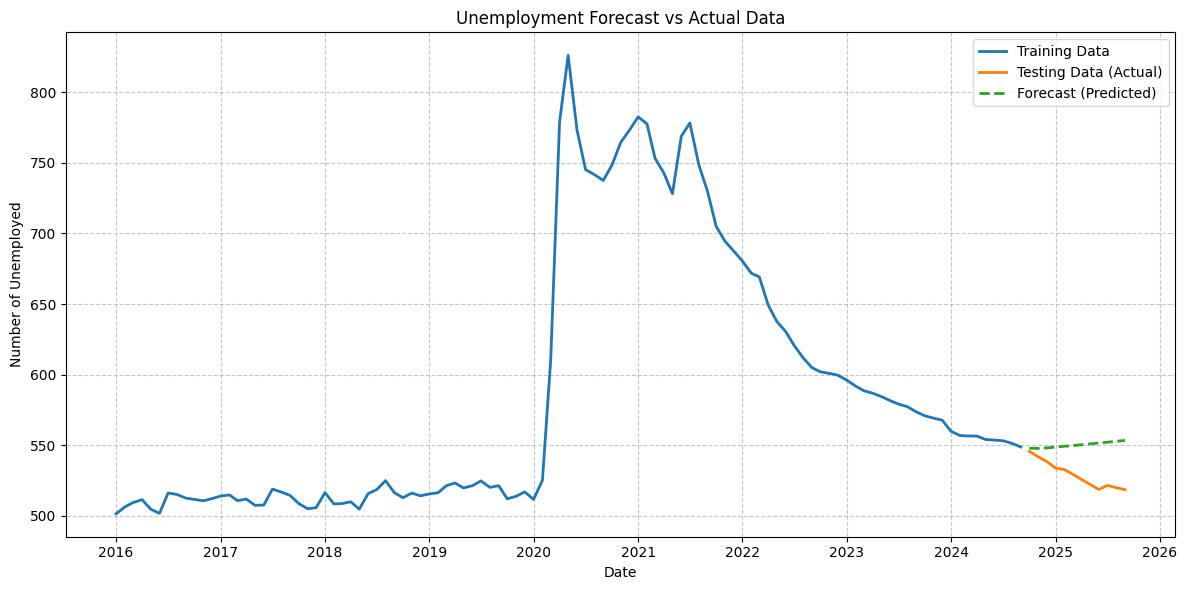

In [ ]:
# Plot actual training data, actual testing data, and predicted testing data
plt.figure(figsize=(12, 6))

# Plot Training Data
plt.plot(in_sample.index, in_sample['unemployed'],
         label='Training Data', linewidth=2, color='tab:blue')

# Plot Testing Data (Actual)
plt.plot(out_sample.index, out_sample['unemployed'],
         label='Testing Data (Actual)', linewidth=2, color='tab:orange')

# Plot Forecast (Predicted) - Using the inverse-transformed variable fcast1_out_sample
plt.plot(fcast1_out_sample.index, fcast1_out_sample,
         '--', linewidth=2, label='Forecast (Predicted)', color='tab:green')

plt.title('Unemployment Forecast vs Actual Data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Number of Unemployed")
plt.tight_layout()
plt.show()

In [ ]:
# Compute the forecast evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual values from the test set and predicted values on the original scale
actual = out_sample['unemployed']
predicted = fcast1_out_sample

# MAE (Mean Absolute Error)
mae = mean_absolute_error(actual, predicted)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(actual, predicted))

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}%")

MAE  : 21.1311
RMSE : 23.7281
MAPE : 4.0293%
